In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

sys.path.append('PerturbVAE')

from model import *
from utils import *
from dataset import *
from PerturbVAE.trainer import *

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
data = sc.read_h5ad('/home/mingxuanzhang/PerturbVAE/replogle.h5ad')
data.var.set_index('gene_name', inplace=True)
mask = ~pd.Index(data.var_names).duplicated(keep=False)
data = data[:, mask].copy()

In [4]:
data

AnnData object with n_obs × n_vars = 118641 × 1185
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'
    uns: 'pathways'

In [5]:
module_df = pd.read_csv('/home/mingxuanzhang/PerturbVAE/modules.csv')
module_df

,module,type,gene
0,0,TF,CEBPD
1,0,TF,ETV6
2,0,TF,NFKB1
3,0,TF,RELB
4,0,target,ABI3BP
...,...,...,...
3467,11,target,ZNF800
3468,11,target,ZNF804A
3469,11,target,ZNF827
3470,11,target,ZNFX1


In [5]:
# Find duplicate indices in data.var
duplicate_indices = data.var.index[data.var.index.duplicated()]
print("Duplicate indices:", duplicate_indices)

Duplicate indices: CategoricalIndex([], categories=['AAMDC', 'AARS', 'ABHD2', 'ABRACL', ..., 'ZPR1', 'ZRANB2', 'ZSCAN16-AS1', 'ZWINT'], ordered=False, dtype='category', name='gene_name')


In [ ]:
# 'HSPA14' in module_df.index

NameError: name 'module_df' is not defined

In [ ]:
# Collapse gene to unique indices
# collapsed_df = module_df.groupby('gene').agg({
#     'module': lambda x: ','.join(map(str, sorted(x))),
# }).reset_index()


# # Set the gene column as the index
# collapsed_df.set_index('gene', inplace=True)

# # Find the intersection of genes between data.var and collapsed_df
# common_genes = data.var.index.intersection(collapsed_df.index)

# # Subset data.var by the intersection of genes
# data = data[: , common_genes].copy()

# # # Add the module and type columns to data.var
# data.var['module'] = collapsed_df.loc[common_genes, 'module']

In [9]:
# norm_data = sc.pp.normalize_total(data[data.obs.gene == 'non-targeting'], copy=True)
# sc.pp.log1p(norm_data)
# norm_data = norm_data.X
# gene_covariance = np.cov(norm_data.X)

In [10]:
# sns.clustermap(np.corrcoef(norm_data.T))

In [7]:
perturbations = set(np.unique(data.obs['gene'].values))
len(perturbations)

682

In [8]:
pathways = []
for pathway in data.uns['pathways'].values():
    pathways.append(set(pathway))
sum([len(pathways[i]) for i in range(len(pathways))])

336

In [9]:
overlap = any(len(set(pathways[i]) & set(pathways[j])) > 0 for i in range(len(pathways)) for j in range(i + 1, len(pathways)))
print("Overlap exists between pathways:" if overlap else "No overlap between pathways.")

No overlap between pathways.


In [10]:
data.obs['treatment'] = 'Untreated'

In [11]:
data

AnnData object with n_obs × n_vars = 118641 × 1185
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'treatment'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'
    uns: 'pathways'

In [12]:
from typing import Any, Dict, List, Literal, Optional

import scipy as sp

def estimate_data_average_treatment_effects(
    adata: anndata.AnnData,
    label_col: str,
    control_label: Any,
    method: Literal["mean", "perturbseq"],
    compute_fdr: bool = False,
) -> anndata.AnnData:
    """

    Parameters
    ----------
    adata: AnnData containing observations and annotated perturbations. Observations
            should be in X
    label_col: column in adata obs dataframe with labels of unique perturbations to
            compute average treatment effects
    control_label: value in label_col to compute effects relative to
    method: method key for computing average treatment effect. "mean" is standard average
            effect, "perturbseq" is effect after normalizing for library size and applying log
    compute_fdr: whether to compute false discovery rate


    Returns
    -------
    AnnData with average treatment effects in X, obs index with perturbation annotations,
    and control perturbation in uns
    """
    if compute_fdr:
        raise NotImplementedError

    valid_methods = ["mean", "perturbseq"]
    assert method in valid_methods, f"Method must be one of {valid_methods}"

    perturbations = adata.obs[label_col].unique()
    assert control_label in perturbations
    alt_labels = [x for x in perturbations if x != control_label]

    X_control = adata[adata.obs[label_col] == control_label].X
    if sp.sparse.issparse(X_control):
        X_control = X_control.toarray()

    if method == "perturbseq":
        X_control = 1e4 * X_control / np.sum(X_control, axis=1, keepdims=True)
        X_control = np.log2(X_control + 1)
    X_control_mean = X_control.mean(0)

    average_effects = []

    for alt_label in tqdm(alt_labels):
        X_alt = adata[adata.obs[label_col] == alt_label].X
        if sp.sparse.issparse(X_alt):
            X_alt = X_alt.toarray()
        if method == "perturbseq":
            X_alt = 1e4 * X_alt / np.sum(X_alt, axis=1, keepdims=True)
            X_alt = np.log2(X_alt + 1)
        X_alt_mean = X_alt.mean(0)
        average_effects.append(X_alt_mean - X_control_mean)

    average_effects = np.stack(average_effects)
    results = anndata.AnnData(
        obs=pd.DataFrame(index=alt_labels),
        X=average_effects,
        var=adata.var.copy(),
        uns=dict(control=control_label),
    )
    return results
treat_effect = estimate_data_average_treatment_effects(
    data,
    label_col = 'gene',
    control_label = 'non-targeting',
    method = "perturbseq",
)

  0%|          | 0/681 [00:00<?, ?it/s]

In [13]:
dataset = PerturbMatchingDataset(data, NTC='non-targeting', p_key='gene')

In [14]:
treat_effect

AnnData object with n_obs × n_vars = 681 × 1185
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'
    uns: 'control'

In [15]:
data

AnnData object with n_obs × n_vars = 118641 × 1185
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'treatment'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'
    uns: 'pathways'

In [16]:
# sampler = MultiClassBatchSampler(
#     labels                = dataset.P_indices,
#     n_classes_per_batch   = 10,            # e.g. 4 classes per batch
#     shuffle_within_class  = True,         # optional
#     drop_last             = False          # drop incomplete last group
# )
# dataloader = DataLoader(dataset,
#                     batch_sampler=sampler)

dataloader = DataLoader(dataset, batch_size=4096, shuffle=True, num_workers=0)


In [17]:
# dataloader = DataLoader(dataset, batch_size=4096, shuffle=True, num_workers=4)

# # Example: Iterate through the DataLoader
# for X, P, C in dataloader:
#     print("Batch X shape:", X.shape)
#     print("Batch P:", P)
#     print("Batch C:", C)
#     break

In [19]:
input_dim = data.shape[-1] 
perturb_dim = len(data.obs['gene'].unique()) - 1  # Exclude the 'NA' control sgRNA
#latent_dim = module_df['module'].max()+1

In [20]:
len(dataloader) * 200 * 0.8

4640.0

In [443]:
pyro.clear_param_store()

tau_init=0.67
latent_dim = 16

vae = VAE(input_dim, latent_dim, 
               len(np.unique(dataset.P_indices)),
                 len(np.unique(dataset.C_indices)),
                 perturb_dim, module_var=data.var['module'].values, tau=tau_init,
                 center_coeff_init=1, use_gene_modules=False, l0_lambda=0.001, l1_lambda=1.0)
vae = vae.to(vae.device)

trainer = VAETrainer(
    vae,
    dataloader,
    lr=1e-3,
    num_epochs=200,
    init_coeff=vae.center_coeff_init,                 
    final_coeff=1e-1,                 
    ramp_steps=10000, 
    tau_init=vae.tau_init,
    tau_end=0.1,
    tau_anneal_steps= 4500,
    #tau_anneal_steps=20000,  
    gate_start=2,
    treat_effect=treat_effect,
)

vae, param_store = trainer.fit()

Training VAE on cuda …


Epochs:   0%|                                                                                                 …

Epoch 1:   0%|                                                                                                …

Epoch 2:   0%|                                                                                                …

Epoch 3:   0%|                                                                                                …

...

Epoch 196:   0%|                                                                                              …

Epoch 197:   0%|                                                                                              …

Epoch 198:   0%|                                                                                              …

Epoch 199:   0%|                                                                                              …

Epoch 200:   0%|                                                                                              …

In [126]:
import pyro.poutine as poutine
model = models[2]
#model = vae
model.eval()
model.device = torch.device('cpu')
model = model.to(model.device)
print(model.device)

param_store = pyro.get_param_store()
for name, value in list(param_store.items()):       
    param_store[name] = value.to(torch.device('cpu'))            

X_p, P, C = torch.tensor(dataset.X_pert, dtype=torch.float32), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)
X_ntc = []
for i in C:
    rand_idx = np.random.randint(0, len(dataset.X_ntc[i]), size=1)[0]
    X_ntc.append(torch.tensor(dataset.X_ntc[i][rand_idx], dtype=torch.float32))
X_ntc = torch.stack(X_ntc, dim=0)
                    
trace = poutine.trace(model.guide).get_trace(X_p, X_ntc, P, C)
trace_model = poutine.trace(poutine.replay(model.model, trace=trace)).get_trace(X_p, X_ntc, P, C)

z  = trace.nodes["z"]["value"]
z0 = trace.nodes["z0"]["value"]

# --- map indices -> readable labels for obs ---
id2pert = {i: p for p, i in dataset.perturbation_dict.items()}
id2cond = {i: c for c, i in dataset.condition_dict.items()}
perturb_names = [id2pert[int(i)] for i in P.tolist()]
cond_names    = [id2cond[int(i)] for i in C.tolist()]

# --- build AnnData objects ---
# Perturbed rows
z_data = sc.AnnData(
    X=z.detach().cpu().numpy(),
    obs=pd.DataFrame({"top_sg": perturb_names, "treatment": cond_names})
)
z_data.obsm["z"] = z.detach().cpu().numpy()

# Matched control rows (NTC)
z0_data = sc.AnnData(
    X=z0.detach().cpu().numpy(),
    obs=pd.DataFrame({"top_sg": ["NTC"] * len(cond_names), "treatment": cond_names})
)

#pi = trace.nodes["pi"]['value']

cpu


/home/mingxuanzhang/anaconda3/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/mingxuanzhang/anaconda3/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [127]:
# from scipy.stats import pearsonr
# from tqdm import trange

# # --- settings ---
# device = torch.device("cpu")
# vae.eval()
# vae = vae.to(device)
# vae.device = device
# n_mc = 50

# # --- data prep ---
# X_p  = torch.tensor(dataset.X_pert, dtype=torch.float32, device=device)
# P    = torch.tensor(dataset.P_indices, device=device)
# C    = torch.tensor(dataset.C_indices, device=device)

# param_store = pyro.get_param_store()
# for name, value in list(param_store.items()):       
#     param_store[name] = value.to(torch.device('cpu'))   

# X_ntc_list = []
# for i in C:
#     ridx = np.random.randint(0, len(dataset.X_ntc[int(i)]), size=1)[0]
#     X_ntc_list.append(torch.tensor(dataset.X_ntc[int(i)][ridx], dtype=torch.float32, device=device))
# X_ntc = torch.stack(X_ntc_list, dim=0)

# # precompute gating probs and chol (globals)
# # q_pi_logits = pyro.param("q_pi_logits")
# # pi = torch.sigmoid(q_pi_logits)                      # (P, Dz)


# L = vae.qr()
# sigma = pyro.param("sigma_fac")
# row_cov = L @ L.T + (sigma**2) * torch.eye(vae.perturbs, device=device)
# chol_P = torch.linalg.cholesky(row_cov)

# preds_p_samples, preds_ntc_samples = [], []

# for _ in trange(n_mc, desc="MC counterfactual sampling"):
#     # ---- sample from guide ----
#     guide_tr = poutine.trace(vae.guide).get_trace(X_p, X_ntc, P, C)

#     # rho: sample from guide (global plate over perturbations)
#     rho_sample = guide_tr.nodes["rho"]["value"]                          # (P, Dz)
#     A = (chol_P @ rho_sample)                                            # (P, Dz)

#     # z0 posterior params
#     z0_dist = guide_tr.nodes["z0"]["fn"]                                 # Normal(mean=..., std=...)
#     z0_mu   = z0_dist.mean                                                # (B, Dz)
#     z0_std  = z0_dist.stddev                                              # (B, Dz)

#     # sample W per MC draw
#     W = vae.gate().to(device)                                # (P, Dz) in {0,1}
#     lin_shift = A[P] * W[P]                                           # (B, Dz)
#     z0_mu_eff = z0_mu * (1. - W[P])                                   # (B, Dz)

#     # ----- PoE gives distribution for z -----
#     z_loc, z_var = vae._VAE__poe(z0_mu_eff, z0_std, lin_shift)           # (B, Dz)
#     z_cf = torch.distributions.Normal(z_loc, z_var.sqrt()).rsample()     # MC sample of perturbed latent

#     # also MC-sample z0 for the NTC arm
#     z0_samp = torch.distributions.Normal(z0_mu, z0_std).rsample()        # (B, Dz)

#     # ----- decode both arms to expected counts μ (do not sample counts) -----
#     # perturbed
#     logits_gene_p = vae.z_decoder(z_cf)
#     mu_p_prob = torch.softmax(logits_gene_p, dim=-1)
#     mu_p = X_p.sum(dim=-1, keepdim=True) * mu_p_prob

#     # control
#     logits_gene_ntc = vae.z_decoder(z0_samp)
#     mu_ntc_prob = torch.softmax(logits_gene_ntc, dim=-1)
#     mu_ntc = X_ntc.sum(dim=-1, keepdim=True) * mu_ntc_prob

#     preds_p_samples.append(mu_p.detach().cpu().numpy())
#     preds_ntc_samples.append(mu_ntc.detach().cpu().numpy())

# # --- average over MC ---
# preds_p   = np.mean(np.stack(preds_p_samples, axis=0), axis=0)
# preds_ntc = np.mean(np.stack(preds_ntc_samples, axis=0), axis=0)
# P_np = P.cpu().numpy()

# # --- Perturb-seq normalization ---
# lib = preds_p.sum(axis=1, keepdims=True).clip(min=1e-8); preds_p = np.log2(1e4 * preds_p / lib + 1.0)
# lib = preds_ntc.sum(axis=1, keepdims=True).clip(min=1e-8); preds_ntc = np.log2(1e4 * preds_ntc / lib + 1.0)

# # --- compute ATE (per perturbation) ---
# n_perts = len(dataset.perturbation_dict)
# n_genes = preds_p.shape[1]
# effect = np.zeros((n_perts, n_genes), dtype=np.float32)

# for pert_name, j in dataset.perturbation_dict.items():
#     mask = (P_np == j)
#     if mask.any():
#         effect[j] = preds_p[mask].mean(axis=0) - preds_ntc[mask].mean(axis=0)

# effect_df = pd.DataFrame(effect, index=list(dataset.perturbation_dict.keys()), columns=treat_effect.var_names)

# # --- align & correlate ---
# effect_aligned = effect_df.loc[treat_effect.obs_names, treat_effect.var_names]
# x = effect_aligned.values.ravel()
# y = treat_effect.X.ravel()
# ate, pval = pearsonr(x, y)
# print(f"MC Counterfactual ATE (n_mc={n_mc}): r={ate:.4f}, p={pval:.2e}")


In [128]:
cls_logits = trace_model.nodes["cls_logits"]["value"]
val_correct = (cls_logits.argmax(dim=-1) == P).sum().item()
val_n = P.size(0)
acc = val_correct / val_n
print(f"Validation accuracy: {acc:.4f}")

Validation accuracy: 0.2515


In [129]:
# z = trace.nodes["z"]["value"]
mu = model.z_decoder(z)

l = X_p.sum(axis=-1, keepdim=True)
mu = torch.softmax(mu, dim=-1)
prediction = l * mu

/home/mingxuanzhang/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


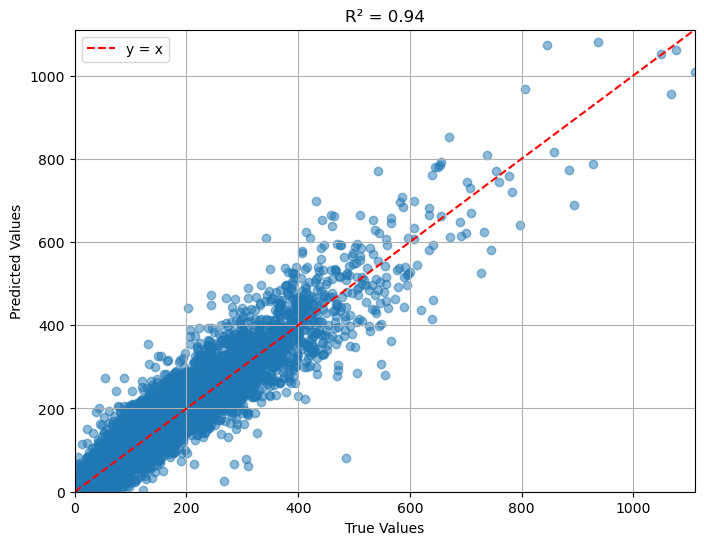

In [97]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

r2 = r2_score(X_p.flatten(), prediction.flatten().detach().numpy())

idx = np.arange(0, X_p.shape[0])
np.random.shuffle(idx)
idx = idx[:1000]

true_vals = X_p[idx].flatten()
pred_vals = prediction.detach().numpy()[idx].flatten()

# Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(true_vals, pred_vals, alpha=0.5)

# y = x line
min_val = min(true_vals.min(), pred_vals.min())
max_val = max(true_vals.max(), pred_vals.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

# Equal axis scaling
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"R² = {r2:.2f}")
plt.grid(True)
plt.legend()
plt.show()


/home/mingxuanzhang/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/mingxuanzhang/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


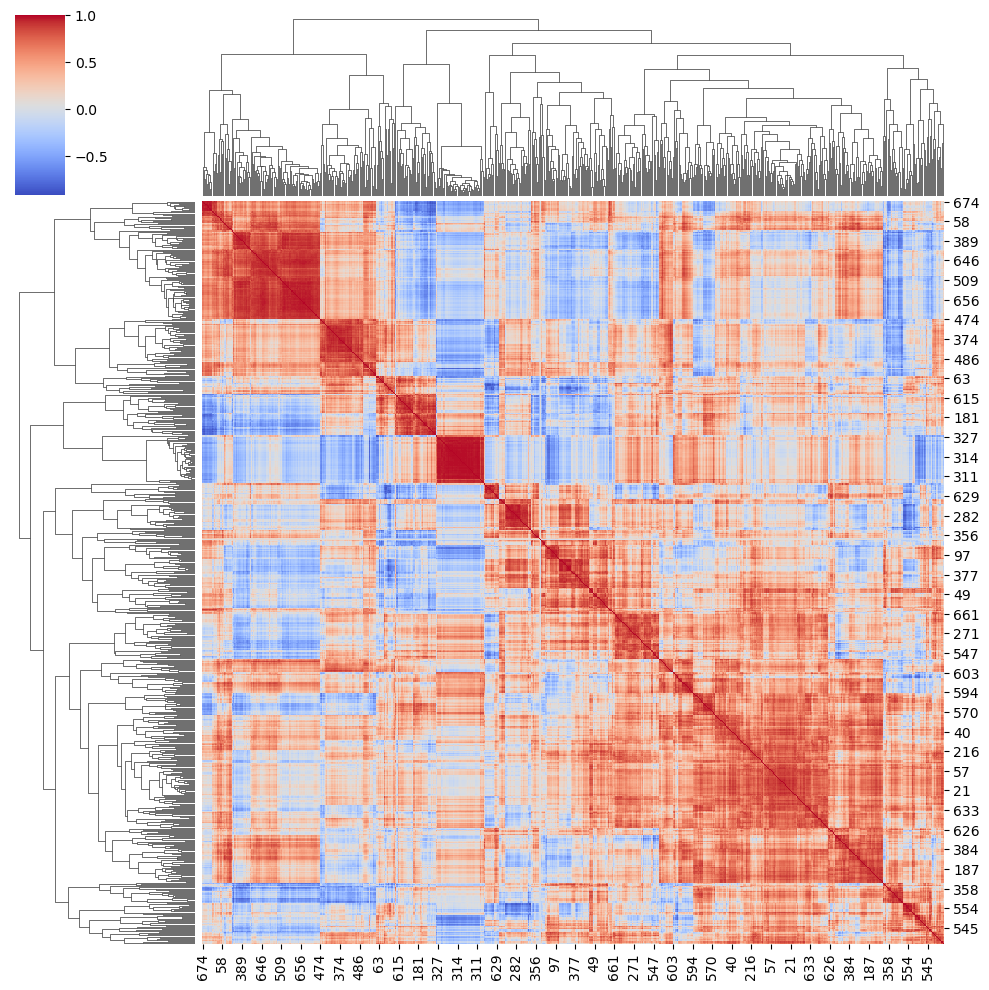

In [130]:
import torch, pyro
import matplotlib.pyplot as plt
import seaborn as sns                   

with torch.no_grad():
    L = vae.qr().cpu()              
    sigma_P = pyro.param("sigma_fac").cpu()

P_ = L.size(0)
Sigma_P_posterior = L @ L.T + sigma_P**2 * torch.eye(P_)
corr = vae._corr(Sigma_P_posterior).numpy()
sns.clustermap(corr, cmap="coolwarm", annot=False)

In [131]:
# z = trace.nodes["z"]["value"]
# z0 = trace.nodes["z0"]["value"]

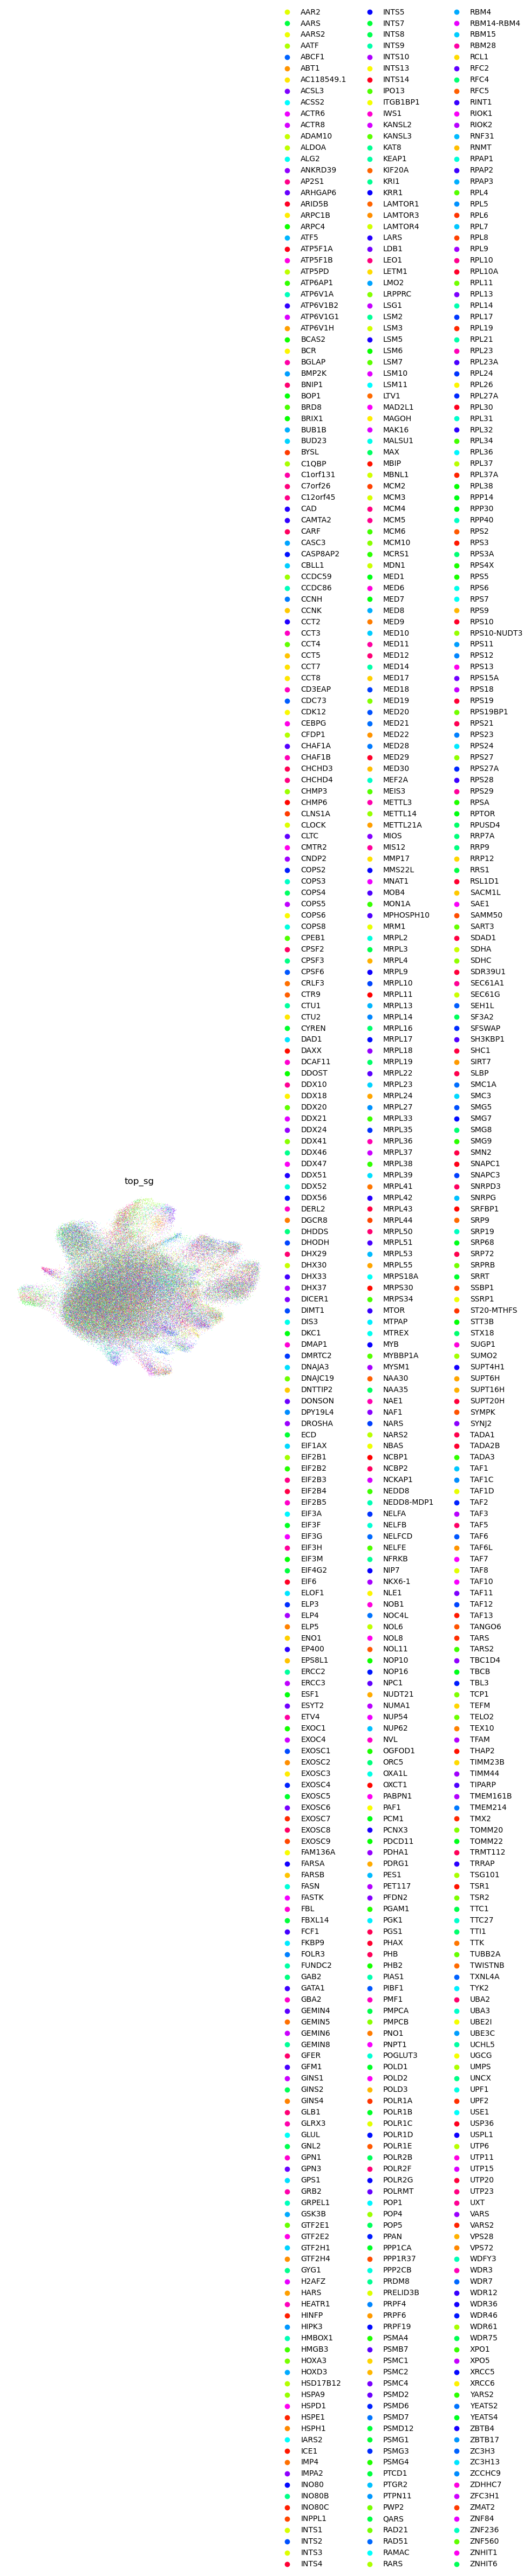

In [132]:
# z_data = data[data.obs.top_sg != 'NTC'].copy()
# z_data.obsm['z'] = z.detach().cpu().numpy()
sc.pp.neighbors(z_data, n_neighbors=15, use_rep='X')
sc.tl.umap(z_data)

import random
n_cats = z_data.obs['top_sg'].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(z_data, color='top_sg', palette=palette, frameon=False)
# sc.pl.umap(z_data, color=['top_sg'], frameon=False, show=True)

In [133]:
num_p = vae.perturbs
d = vae.latent_dim
Sigma_P_posterior = vae._corr(Sigma_P_posterior)
z_bar = torch.zeros(num_p, d)
counts = torch.zeros(num_p)
for p in range(num_p):
    mask = (P == p)
    if mask.any():
        z_bar[p] = z[mask].mean(0)
        counts[p] = mask.sum()

# (Optional) skip perturbations with very few cells
valid = counts > 2
Sigma_z = torch.corrcoef(z_bar[valid])          # (P_valid × P_valid)
Sigma_P_posterior = Sigma_P_posterior[valid][:, valid]              # align shapes

In [134]:
def flat_triu(M):
    idx = torch.triu_indices(M.size(0), M.size(1), offset=1)
    return M[idx[0], idx[1]]

rho_flat  = flat_triu(Sigma_P_posterior).numpy()
z_flat    = flat_triu(Sigma_z.detach()).numpy()

from scipy.stats import spearmanr, pearsonr
r_s, p_s = spearmanr(rho_flat, z_flat)
r_p, p_p = pearsonr(rho_flat, z_flat)

print(f"Spearman ρ = {r_s:.3f}  (p = {p_s:.1e})")
print(f" Pearson  r = {r_p:.3f}  (p = {p_p:.1e})")

Spearman ρ = 0.682  (p = 0.0e+00)
 Pearson  r = 0.693  (p = 0.0e+00)


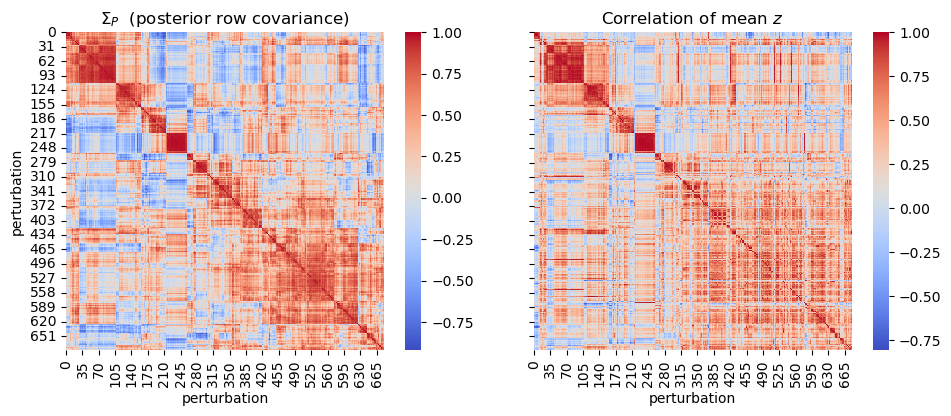

In [135]:
import numpy as np, seaborn as sns, matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
import seaborn as sns, matplotlib.pyplot as plt
from matplotlib import gridspec

import torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list


link = linkage(Sigma_P_posterior, method="average", metric="euclidean")
order = leaves_list(link)              # permutation indices, shape (P,)

# ── 2.  apply the same permutation to both matrices ─────────────────
SigmaP_ord = Sigma_P_posterior[order][:, order]

# Sigma_z : correlation between perturbation-mean z’s  (P × P)
Sigmaz_ord = Sigma_z.detach().cpu().numpy()[order][:, order]


# ── 3.  plot side-by-side heat-maps ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

sns.heatmap(SigmaP_ord, cmap="coolwarm", square=True, ax=axes[0])
axes[0].set_title(r"$\Sigma_P$  (posterior row covariance)")
axes[0].set_xlabel("perturbation"); axes[0].set_ylabel("perturbation")

sns.heatmap(Sigmaz_ord, cmap="coolwarm", square=True, ax=axes[1])
axes[1].set_title("Correlation of mean $z$")
axes[1].set_xlabel("perturbation")

# plt.title(f"Spearman ρ = {r_s:.3f}  Pearson r = {r_p:.3f}")
plt.tight_layout()
plt.show()

In [136]:
n_classes = P.unique().shape[0]
centroids = torch.stack([z[P==k].mean(0) for k in range(n_classes)])
inter = centroids.var(0).sum()
intra = (z - centroids[P]).var(0).sum()
print("inter / intra variance :", inter.item() / intra.item())


inter / intra variance : 0.5684228073459348


In [137]:
# z0_data = data.copy()
# z0_data.obsm['z0'] = z0.detach().cpu().numpy()
# sc.pp.neighbors(z0_data, use_rep='X', n_neighbors=15)
# sc.tl.umap(z0_data)
# sc.pl.umap(z0_data, color=['treatment', 'top_sg'], frameon=False, show=True)

In [138]:
# pi = trace.nodes["pi"]['value']
# pi

In [139]:
W = vae.gate(deterministic=True).cpu().detach().numpy()

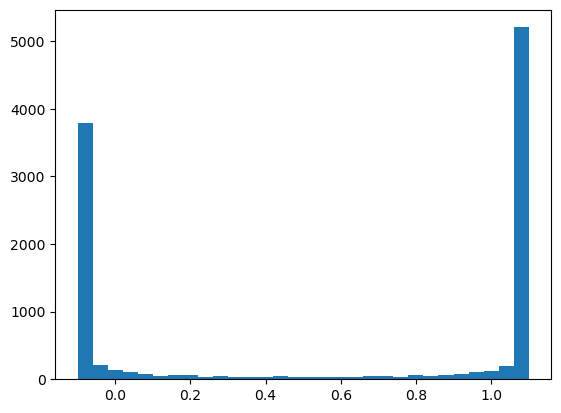

In [140]:
plt.hist(W.flatten(), bins=30)
plt.show()

In [141]:
W_bin = (W > 0.5).astype(float)

<Axes: >

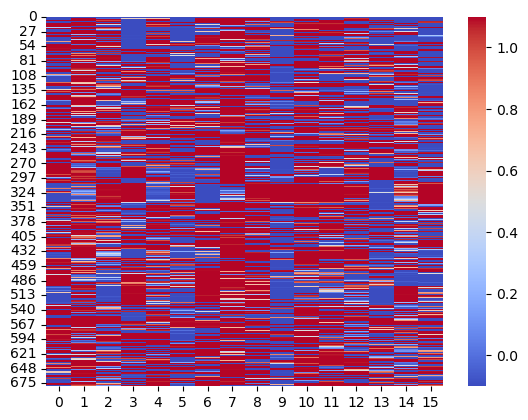

In [142]:
sns.heatmap(W, cmap="coolwarm")

In [143]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
with torch.no_grad():
    L = vae.qr().cpu()              
    sigma_P = pyro.param("sigma_fac").cpu()

P_ = L.size(0)
Sigma_P_posterior = L @ L.T + sigma_P**2 * torch.eye(P_)

C = vae._corr(Sigma_P_posterior).detach().cpu().numpy()
D = 1.0 - C  # distance
Z_link = linkage(D[np.triu_indices_from(D, 1)], method='ward')
# groups = fcluster(Z_link, t=0.5, criterion='distance')  # tune t

In [144]:
C.shape

(681, 681)

In [145]:
all_genes = [gene for genes in data.uns['pathways'].values() for gene in genes if gene != 'LSM5']
gene_ids = [dataset.perturbation_dict[g] for g in all_genes]
cov_subset = C[np.ix_(gene_ids, gene_ids)].clip(-1, 1)

In [146]:
cov_subset.max()

1.0

In [147]:
D = 1.0 - cov_subset  # distance
Z_link = linkage(D[np.triu_indices_from(D, 1)], method='ward')

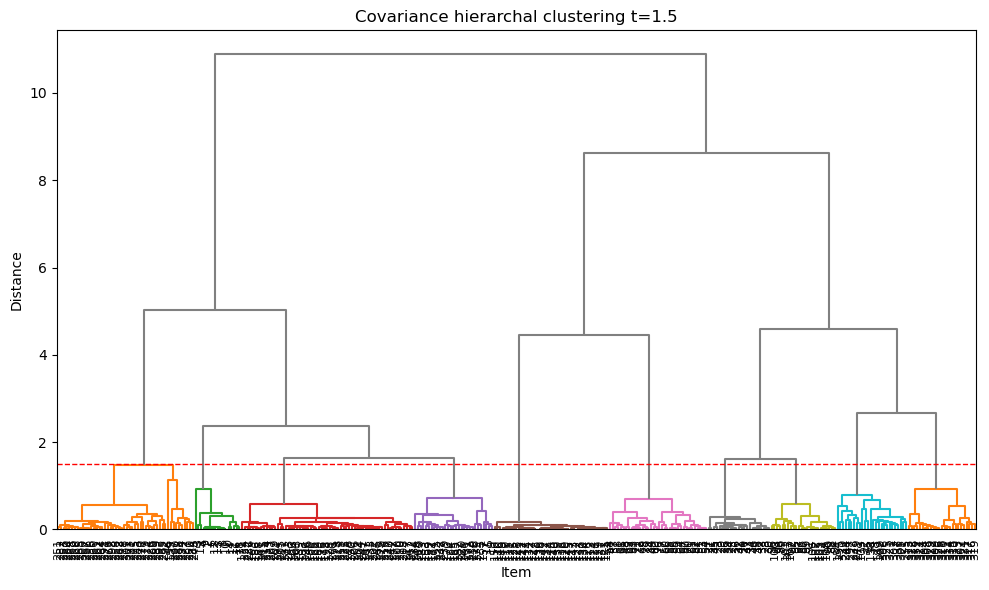

In [148]:
t = 1.5  # your cut in the same distance scale as Z_link

plt.figure(figsize=(10, 6))
dendrogram(
    Z_link,
    color_threshold=t,            # <-- color branches by your cut
    above_threshold_color="gray", # color for branches above the cut
    labels=np.arange(len(cov_subset)),     # optional
    leaf_rotation=90,
    leaf_font_size=8,
)
plt.axhline(y=t, color="red", linestyle="--", linewidth=1)
plt.title(f"Covariance hierarchal clustering t={t}")
plt.xlabel("Item")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Cluster labels at the same cut
groups = fcluster(Z_link, t=t, criterion='distance')

In [149]:
from collections import Counter

# Flatten all genes from all pathways
#all_genes = [gene for genes in data.uns['pathways'].values() for gene in genes]

# Count how many times each gene appears
gene_counts = Counter(all_genes)

# Find genes that appear in more than one pathway
shared_genes = [gene for gene, count in gene_counts.items() if count > 1]

if shared_genes:
    print(f"⚠️ {len(shared_genes)} genes are shared across pathways:")
    print(shared_genes[:20])  # show first 20 for inspection
else:
    print("✅ Each gene appears in exactly one pathway.")


#pert df
pathway_genes = np.concatenate([i for i in list(data.uns['pathways'].values())])
pathway_genes = pathway_genes[pathway_genes != 'LSM5']
print(len(pathway_genes))
print(len(all_genes))
perts = pd.DataFrame(groups, index=all_genes, columns=['cluster'])
perts = perts.loc[pathway_genes]

#pathway df
gene_to_pathway = {
    gene: pathway
    for pathway, genes in data.uns['pathways'].items()
    for gene in genes if gene != 'LSM5'
}
pathway_df = pd.DataFrame.from_dict(gene_to_pathway, orient="index", columns=["cluster"])


perts = perts.drop(shared_genes, errors="ignore")
pathway_df = pathway_df.drop(shared_genes, errors="ignore")

print("After removal:")
print("perts size     :", perts.shape)
print("pathway_df size:", pathway_df.shape)

✅ Each gene appears in exactly one pathway.
335
335
After removal:
perts size     : (335, 1)
pathway_df size: (335, 1)


In [150]:
perts

,cluster
ZC3H3,2
ZFC3H1,2
CAMTA2,9
DHX29,2
DIS3,2
...,...
SNRPG,10
TIPARP,10
TTC27,10
TXNL4A,9


In [151]:
from sklearn.metrics import adjusted_rand_score

# Align on the same gene index
perts_aligned = perts.loc[pathway_df.index]

# Compute ARI
ari = adjusted_rand_score(pathway_df["cluster"], perts_aligned["cluster"])
print("ARI =", ari)

ARI = 0.7213205058158761


In [152]:
perts_aligned["cluster"]

ZC3H3      2
ZFC3H1     2
CAMTA2     9
DHX29      2
DIS3       2
          ..
SNRPG     10
TIPARP    10
TTC27     10
TXNL4A     9
USPL1     10
Name: cluster, Length: 335, dtype: int32

In [153]:
pathway_df['gene'] = pathway_df.index.copy()
pathway_df.columns = ['pathway', 'gene']
pathway_df

,pathway,gene
ZC3H3,EXOSOME,ZC3H3
ZFC3H1,EXOSOME,ZFC3H1
CAMTA2,EXOSOME,CAMTA2
DHX29,EXOSOME,DHX29
DIS3,EXOSOME,DIS3
...,...,...
SNRPG,SPLICEOSOME,SNRPG
TIPARP,SPLICEOSOME,TIPARP
TTC27,SPLICEOSOME,TTC27
TXNL4A,SPLICEOSOME,TXNL4A


In [154]:
perts_aligned['gene'] = perts_aligned.index.copy()
perts_aligned

,cluster,gene
ZC3H3,2,ZC3H3
ZFC3H1,2,ZFC3H1
CAMTA2,9,CAMTA2
DHX29,2,DHX29
DIS3,2,DIS3
...,...,...
SNRPG,10,SNRPG
TIPARP,10,TIPARP
TTC27,10,TTC27
TXNL4A,9,TXNL4A


In [155]:
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment
from scipy.stats import hypergeom

try:
    from statsmodels.stats.multitest import multipletests
    _HAS_SM = True
except Exception:
    _HAS_SM = False


def align_and_summarize(
    clusters_df: pd.DataFrame,
    pathways_df: pd.DataFrame,
    gene_col: str = "gene",
    cluster_col: str = "cluster",
    pathway_col: str = "pathway",
    min_pathway_size: int = 1,
):
    # 1) Merge on gene
    df = pd.merge(
        clusters_df[[gene_col, cluster_col]],
        pathways_df[[gene_col, pathway_col]],
        on=gene_col,
        how="inner",
        validate="one_to_one"
    ).dropna(subset=[cluster_col, pathway_col]).copy()

    # Optional: filter tiny pathways to stabilize Hungarian/enrichment
    if min_pathway_size > 1:
        keep_path = df[pathway_col].value_counts()
        keep_path = keep_path[keep_path >= min_pathway_size].index
        df = df[df[pathway_col].isin(keep_path)].copy()

    # Cast to string for safe indexing
    y_true = df[pathway_col].astype(str).values
    y_pred = df[cluster_col].astype(str).values
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    # 2) Contingency (rows=pathways, cols=clusters)
    C = pd.crosstab(df[pathway_col].astype(str), df[cluster_col].astype(str))
    contingency_df = C.reindex(index=true_labels, columns=pred_labels, fill_value=0)

    # 3) Hungarian alignment to maximize correct assignments (sum of diagonal)
    M = contingency_df.values
    row_ind, col_ind = linear_sum_assignment(M.max() - M)  # maximize
    mapping = {pred_labels[j]: true_labels[i] for i, j in zip(row_ind, col_ind)}

    # 4) Remap clusters → pathways and compute metrics
    mapped = np.array([mapping.get(cl, None) for cl in y_pred], dtype=object)
    is_match = mapped == y_true
    accuracy = float(is_match.mean())

    # Label-based external clustering metrics (label strings are fine)
    ari = adjusted_rand_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)

    # 5) Per-cluster purity & mapped target
    purity_rows = []
    for cl, g in df.groupby(cluster_col):
        majority = g[pathway_col].mode().iat[0]
        purity = (g[pathway_col] == majority).mean()
        purity_rows.append({
            "cluster": str(cl),
            "size": len(g),
            "mapped_pathway": mapping.get(str(cl), None),
            "purity": purity
        })
    purity_df = pd.DataFrame(purity_rows).sort_values("cluster").set_index("cluster")

    # 6) Normalized contingency for plotting
    contingency = contingency_df.copy()
    contingency_row_norm = contingency.div(contingency.sum(axis=1).replace(0, np.nan), axis=0)
    contingency_col_norm = contingency.div(contingency.sum(axis=0).replace(0, np.nan), axis=1)

    # 7) Pathway↔cluster enrichment (hypergeometric with FDR)
    #    N = total genes, K = pathway size, n = cluster size, k = overlap
    N = len(df)
    path_sizes = contingency.sum(axis=1)
    cl_sizes = contingency.sum(axis=0)
    records = []
    for p in contingency.index:
        K = int(path_sizes.loc[p])
        for c in contingency.columns:
            n = int(cl_sizes.loc[c])
            k = int(contingency.loc[p, c])
            # p-value: probability of ≥k overlap by chance
            pval = hypergeom.sf(k - 1, N, K, n) if k > 0 else 1.0
            records.append({"pathway": p, "cluster": c, "k": k, "K": K, "n": n, "N": N, "pval": float(pval)})

    enrich_df = pd.DataFrame(records)
    if _HAS_SM and len(enrich_df) > 0:
        enrich_df["qval"] = multipletests(enrich_df["pval"].values, method="fdr_bh")[1]
    else:
        # Bonferroni fallback
        m = max(len(enrich_df), 1)
        enrich_df["qval"] = np.minimum(enrich_df["pval"] * m, 1.0)

    # Signed/visual score: -log10(q)
    with np.errstate(divide="ignore"):
        enrich_df["neglog10q"] = -np.log10(np.clip(enrich_df["qval"].values, 1e-300, 1.0))

    # 8) Attach mapped labels into the merged table
    df["mapped_pathway"] = mapped
    df["is_match"] = is_match

    return {
        "merged": df[[gene_col, cluster_col, pathway_col, "mapped_pathway", "is_match"]].rename(
            columns={gene_col: "gene", cluster_col: "cluster", pathway_col: "pathway"}
        ),
        "mapping": mapping,
        "accuracy": accuracy,
        "ari": ari,
        "ami": ami,
        "purity_df": purity_df,
        "contingency": contingency,
        "contingency_row_norm": contingency_row_norm,
        "contingency_col_norm": contingency_col_norm,
        "enrichment": enrich_df,
    }


In [156]:
results = align_and_summarize(
    clusters_df=perts_aligned,          # gene↦cluster from covariance HC
    pathways_df=pathway_df,             # gene↦pathway ground truth
    gene_col="gene",
    cluster_col="cluster",
    pathway_col="pathway",
    min_pathway_size=1,                 # optional: filter tiny pathways
)

print("Best cluster→pathway mapping:")
for cl, pw in results["mapping"].items():
    print(f"  {cl} → {pw}")

print(f"\nGlobal alignment accuracy: {results['accuracy']:.3f}")
print(f"ARI: {results['ari']:.3f} | AMI: {results['ami']:.3f}\n")

print("Per-cluster purity:")
print(results["purity_df"])

Best cluster→pathway mapping:
  2 → EXOSOME
  7 → MEDIATOR_COMPLEX
  6 → MT_PROTEIN_TRANSLOCATION
  8 → NUCLEOTIDE_EXCISION_REPAIR
  5 → S39_RIBOSOMAL_UNIT
  3 → S40_RIBOSOMAL_UNIT
  1 → S60_RIBOSOMAL_UNIT
  10 → SPLICEOSOME

Global alignment accuracy: 0.821
ARI: 0.721 | AMI: 0.814

Per-cluster purity:
         size              mapped_pathway    purity
cluster                                            
1          50          S60_RIBOSOMAL_UNIT  0.940000
10         25                 SPLICEOSOME  1.000000
2          17                     EXOSOME  0.941176
3          63          S40_RIBOSOMAL_UNIT  1.000000
4          29                        None  0.896552
5          42          S39_RIBOSOMAL_UNIT  1.000000
6          36    MT_PROTEIN_TRANSLOCATION  1.000000
7          23            MEDIATOR_COMPLEX  1.000000
8          24  NUCLEOTIDE_EXCISION_REPAIR  0.958333
9          26                        None  0.269231


/var/tmp/ipykernel_3859360/2795547488.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(all_cats))  # any qualitative map works


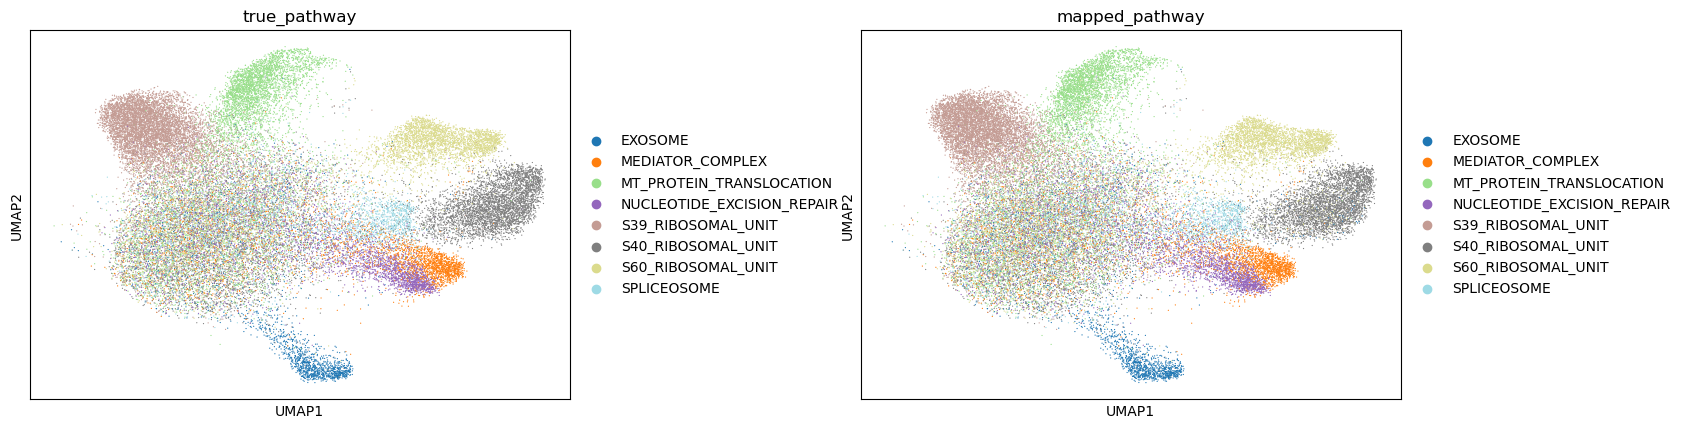

In [157]:
import numpy as np
import pandas as pd
from matplotlib.colors import to_hex
import matplotlib.pyplot as plt

# --- your existing setup ---
results_df = results['merged']
clustered_genes = results_df["gene"].unique()

z_sub = z_data[z_data.obs["top_sg"].isin(clustered_genes)].copy()

gene_to_true   = dict(zip(results_df["gene"], results_df["pathway"]))
gene_to_mapped = dict(zip(results_df["gene"], results_df["mapped_pathway"]))

z_sub.obs["true_pathway"]   = z_sub.obs["top_sg"].map(gene_to_true)
z_sub.obs["mapped_pathway"] = z_sub.obs["top_sg"].map(gene_to_mapped)

# Drop NA mapped rows
z_sub = z_sub[z_sub.obs["mapped_pathway"].notna() & (z_sub.obs["mapped_pathway"] != "NA")].copy()

# --- NEW: enforce identical palettes for both columns ---
# 1) Make both columns categorical with the SAME category set & order
true_vals   = pd.Index(z_sub.obs["true_pathway"].dropna().unique().astype(str))
mapped_vals = pd.Index(z_sub.obs["mapped_pathway"].dropna().unique().astype(str))
all_cats = pd.Index(np.unique(true_vals.union(mapped_vals)))  # sorted union

cat_dtype = pd.api.types.CategoricalDtype(categories=all_cats, ordered=False)
z_sub.obs["true_pathway"]   = z_sub.obs["true_pathway"].astype("string").astype(cat_dtype)
z_sub.obs["mapped_pathway"] = z_sub.obs["mapped_pathway"].astype("string").astype(cat_dtype)

# 2) Build a single color palette over all categories
cmap = plt.cm.get_cmap("tab20", len(all_cats))  # any qualitative map works
shared_palette = {cat: to_hex(cmap(i)) for i, cat in enumerate(all_cats)}

# 3) Write per-column color lists in each column's category order
true_order   = list(z_sub.obs["true_pathway"].cat.categories)
mapped_order = list(z_sub.obs["mapped_pathway"].cat.categories)

z_sub.uns["true_pathway_colors"]   = [shared_palette[c] for c in true_order]
z_sub.uns["mapped_pathway_colors"] = [shared_palette[c] for c in mapped_order]

# --- Plot (colors now matched across panels) ---
import scanpy as sc
sc.pl.umap(
    z_sub,
    color=["true_pathway", "mapped_pathway"],
    wspace=0.4,
)

# Check W consistency

In [21]:
data

AnnData object with n_obs × n_vars = 118641 × 1185
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'treatment'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'
    uns: 'pathways'

In [22]:
dataset.X_pert.shape

(116641, 1185)

In [31]:
def _initialize_vaes(dataset, tau_init=2.0, n_models=5):
    vaes = []
    for _ in range(n_models):
        # Initialize a new VAE for each model
        input_dim = data.shape[-1] 
        vae = VAE(input_dim, 16, 
               len(np.unique(dataset.P_indices)),
                 len(np.unique(dataset.C_indices)),
                 perturb_dim, module_var=None, tau=tau_init,
                 center_coeff_init=1, use_gene_modules=False, l0_lambda=0.001, l1_lambda=1.0)
        vae = vae.to(vae.device)
        vaes.append(vae)
    return vaes

In [32]:
models = _initialize_vaes(dataset, n_models=5)
param_stores = []

In [33]:
import tqdm

In [34]:
for i in tqdm.tqdm(range(len(models))):
    pyro.clear_param_store()
    trainer = VAETrainer(
        models[i],
        dataloader,
        lr=1e-3,
        num_epochs=200,
        init_coeff=0.1,                 
        final_coeff=1e-1,                 
        ramp_steps=10000, 
        tau_init=0.67,
        tau_end=0.1,
        tau_anneal_steps= 4500,
        #tau_anneal_steps=20000,  
        gate_start=2,
        treat_effect=treat_effect,
    )
    best_model, best_param_store = trainer.fit()
    models[i] = best_model
    param_stores.append(best_param_store)

  0%|                                                                                                                                            | 0/5 [00:00<?, ?it/s]

Training VAE on cuda …


Epochs:   0%|                                                                                                 …

Epoch 1:   0%|                                                                                                …

Epoch 2:   0%|                                                                                                …

...

Epoch 197:   0%|                                                                                              …

Epoch 198:   0%|                                                                                              …

Epoch 199:   0%|                                                                                              …

Epoch 200:   0%|                                                                                              …

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [1:42:54<00:00, 1234.88s/it]


In [35]:
from utils import *

In [36]:
def _model_trace(model, dataset):
    model.eval()
    model.device = torch.device('cpu')
    model = model.to(model.device)
    print(model.device)

    param_store = pyro.get_param_store()
    for name, value in list(param_store.items()):       
        param_store[name] = value.to(torch.device('cpu'))            

    X_p, P, C = torch.tensor(dataset.X_pert, dtype=torch.float32), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)
    X_ntc = []
    for i in C:
        rand_idx = np.random.randint(0, len(dataset.X_ntc[i]), size=1)[0]
        X_ntc.append(torch.tensor(dataset.X_ntc[i][rand_idx], dtype=torch.float32))
    X_ntc = torch.stack(X_ntc, dim=0)
                        
    trace = poutine.trace(model.guide).get_trace(X_p, X_ntc, P, C)
    trace_model = poutine.trace(poutine.replay(model.model, trace=trace)).get_trace(X_p, X_ntc, P, C)


    return trace, trace_model

In [37]:
Ws, Pis = [], []             # graph-level statistics
Zs, Z0s, Rhos, corrs = [], [], [], []    # optional latent diagnostics

for run_idx, vae in enumerate(tqdm.tqdm(models, desc="collect posteriors")):

    # --------  move model + params to CPU and eval mode  ----------
    vae.eval()
    vae.to("cpu")
    vae.device = torch.device('cpu')
    pyro.get_param_store().set_state(param_stores[run_idx])         

    # print(torch.mean(q_pi))
    # print(torch.max(q_pi))

    # --------  draw one trace if you want latent snapshots  -------
    param_store = pyro.get_param_store()
    for name, value in list(param_store.items()):       
        param_store[name] = value.to(torch.device('cpu'))            

    X_p, P, C = torch.tensor(dataset.X_pert, dtype=torch.float32), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)
    X_ntc = []
    for i in C:
        rand_idx = np.random.randint(0, len(dataset.X_ntc[i]), size=1)[0]
        X_ntc.append(torch.tensor(dataset.X_ntc[i][rand_idx], dtype=torch.float32))
    X_ntc = torch.stack(X_ntc, dim=0)
                        
    trace = poutine.trace(vae.guide).get_trace(X_p, X_ntc, P, C)
    trace_model = poutine.trace(poutine.replay(vae.model, trace=trace)).get_trace(X_p, X_ntc, P, C)

    Zs.append(trace.nodes["z"]["value"].detach().cpu())
    Z0s.append(trace.nodes["z0"]["value"].detach().cpu())
    Rhos.append(trace.nodes["rho"]["value"].detach().cpu())
    S_map = vae.gate().detach().cpu().numpy()
    Ws.append(S_map)

    rho_cov = vae._get_cov()
    rho_corr = vae._corr(rho_cov).detach().cpu().numpy()
    corrs.append(rho_corr)


collect posteriors:   0%|                                                                                                                        | 0/5 [00:00<?, ?it/s]

collect posteriors: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:33<00:00,  6.71s/it]


In [38]:
def upper_tri_vec(M):
    iu = np.triu_indices_from(M, k=1)
    return M[iu]

In [39]:
from scipy.stats import pearsonr
n = len(corrs)
pairwise_P = np.eye(n, dtype=float)

for (i, j) in itertools.combinations(range(n), 2):
    v1 = upper_tri_vec(corrs[i])
    v2 = upper_tri_vec(corrs[j])
    r, p = pearsonr(v1, v2)
    pairwise_P[i, j] = r
    pairwise_P[j, i] = r

# ---- summary stats ----
tri_i, tri_j = np.triu_indices(n, k=1)
vals = pairwise_P[tri_i, tri_j]
print("\n=== Consistency cov ===")
print(f"Mean r: {vals.mean():.4f} | Median r: {np.median(vals):.4f} | Min r: {vals.min():.4f} | Max r: {vals.max():.4f}")


=== Consistency cov ===
Mean r: 0.7276 | Median r: 0.7227 | Min r: 0.6855 | Max r: 0.7796


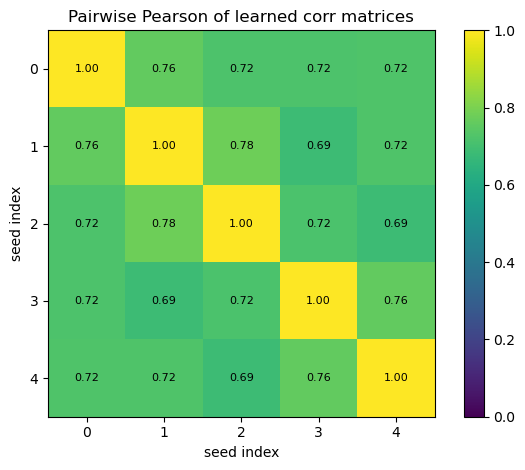

In [40]:
fig, ax = plt.subplots()
im = ax.imshow(pairwise_P, vmin=0, vmax=1)


n = pairwise_P.shape[0]
for i in range(n):
    for j in range(n):
        v = pairwise_P[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color=("white" if v < 0.5 else "black"), fontsize=8)

# (optional) label ticks with actual seed values if you have `seeds = [0,1,2,3,4]`
try:
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
except NameError:
    pass  # falls back to index labels

ax.set_title("Pairwise Pearson of learned corr matrices")
ax.set_xlabel("seed index")
ax.set_ylabel("seed index")
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
from matplotlib.gridspec import GridSpec

def plot_corrs_with_shared_order(corr_list, labels=None, method="average"):
    assert len(corr_list) >= 1, "Provide at least one correlation matrix."
    G = corr_list[0].shape[0]
    assert all(C.shape == (G, G) for C in corr_list), "All matrices must be the same size and square."

    # cluster on first matrix
    C0 = corr_list[0]
    D0 = 1.0 - C0
    np.fill_diagonal(D0, 0.0)
    Z = linkage(squareform(D0, checks=False), method=method)
    order = leaves_list(Z)

    ordered_corrs = [C[np.ix_(order, order)] for C in corr_list]
    if labels is not None:
        labels = [labels[i] for i in order]

    n = len(ordered_corrs)
    fig = plt.figure(figsize=(3.2*n + 2.5, 3.2 + 1.6))
    gs = GridSpec(2, n, height_ratios=[1, 8], hspace=0.08, wspace=0.15, figure=fig)

    # dendrogram above first heatmap
    ax_dend = fig.add_subplot(gs[0, 0])
    dendrogram(Z, no_labels=True, color_threshold=None)
    ax_dend.set_xticks([]); ax_dend.set_yticks([])
    for spine in ax_dend.spines.values():
        spine.set_visible(False)

    # heatmaps
    vmin, vmax = 0.3, 1.0
    ims, heat_axes = [], []
    for j, C in enumerate(ordered_corrs):
        ax = fig.add_subplot(gs[1, j])
        im = ax.imshow(C, vmin=vmin, vmax=vmax, aspect="auto", interpolation="nearest", cmap='coolwarm')
        ims.append(im)
        heat_axes.append(ax)
        ax.set_title(f"Matrix {j+1}", fontsize=10, pad=6)

        if labels is not None and G <= 60:
            ax.set_xticks(np.arange(G)); ax.set_yticks(np.arange(G))
            ax.set_xticklabels(labels, fontsize=7, rotation=90)
            ax.set_yticklabels(labels, fontsize=7)
        else:
            ax.set_xticks([]); ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

    # shared colorbar without creating a new subplot that covers the last panel
    cbar = fig.colorbar(ims[-1], ax=heat_axes, fraction=0.046, pad=0.04)
    cbar.set_label("correlation", fontsize=9)

    plt.tight_layout()
    plt.show()

/var/tmp/ipykernel_3859360/4111610708.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


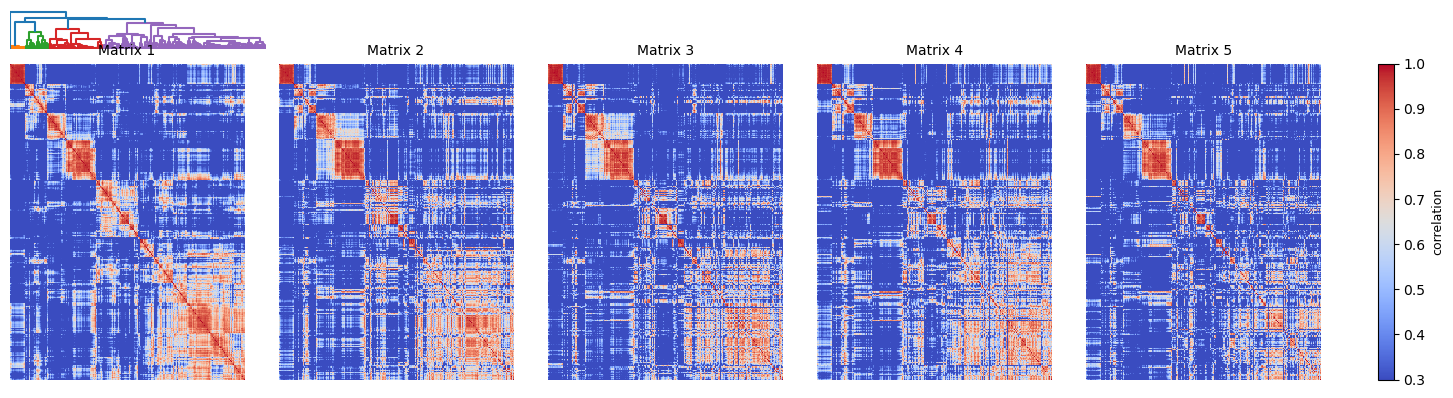

In [42]:
plot_corrs_with_shared_order(corrs, labels=None, method="average")

In [43]:
from utils import *

In [44]:
Ws = [model.gate(deterministic=True).cpu().detach().numpy() for model in models]

In [45]:
W_bins = [(W > 0.5).astype(float) for W in Ws]
W_bins

[array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 1., 0.],
        [1., 1., 1., ..., 0., 1., 1.],
        ...,
        [1., 1., 0., ..., 1., 1., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [1., 1., 1., ..., 1., 1., 0.]]),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 1., 1., ..., 0., 1., 0.],
        ...,
        [1., 0., 1., ..., 0., 1., 1.],
        [1., 1., 1., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 1., 0.]]),
 array([[0., 0., 0., ..., 1., 0., 0.],
        [0., 1., 1., ..., 1., 0., 0.],
        [1., 0., 0., ..., 0., 1., 1.],
        ...,
        [1., 1., 1., ..., 0., 0., 0.],
        [0., 1., 0., ..., 1., 0., 1.],
        [1., 1., 1., ..., 1., 1., 0.]]),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.],
        [0., 0., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 0., 1.],
        [1., 1., 0., ..., 1., 0., 1.],
        [0., 1., 1., ..., 0., 0., 0.]]),
 arr

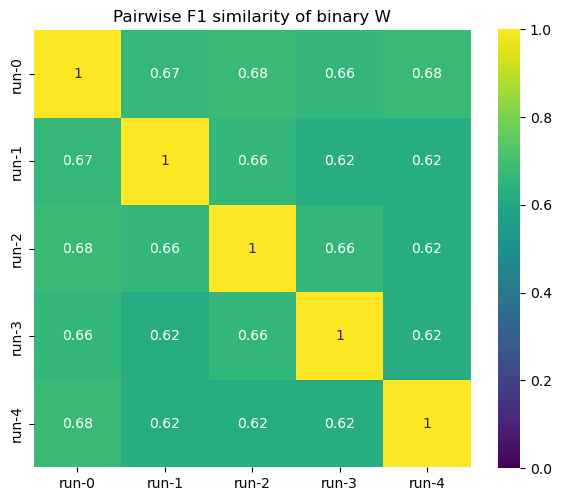

Mean f1 = 0.648 ± 0.023


In [46]:
compare_W_runs_binary(W_bins, align=True)

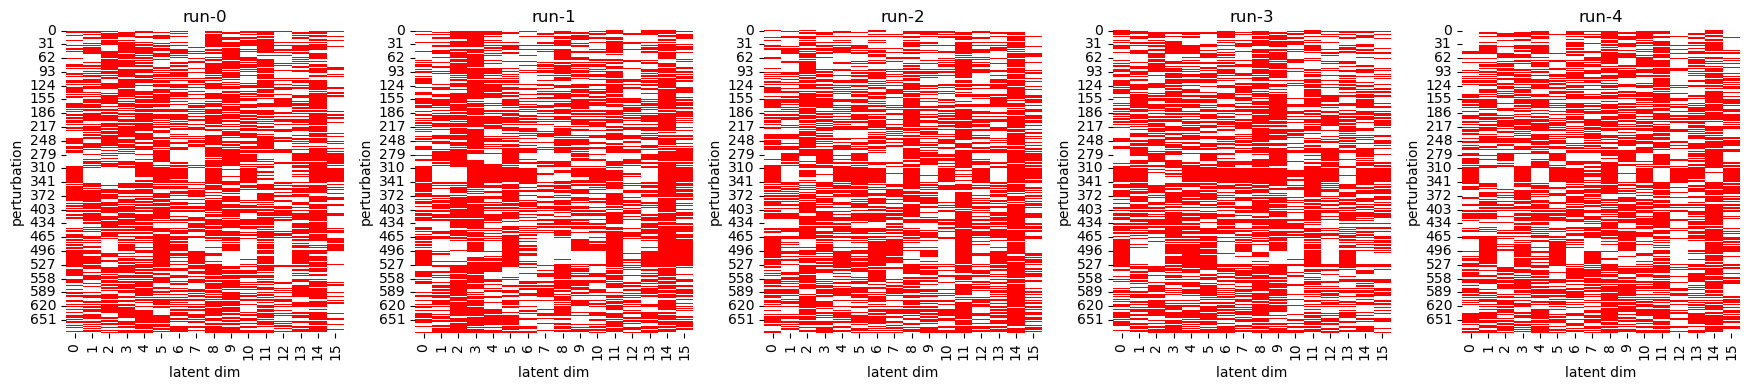

In [47]:
plot_aligned_Ws(W_bins)

In [83]:
torch.save(models[0].state_dict(), "vae_torch_params.pth")

In [ ]:
pyro.get_param_store().set_state(param_stores[0]).save("vae_pyro_params.pyro")